# Auditoría de la pendiente negativa del benchmark histórico

## Objetivo

Auditar por qué la regresión de desarrollo ya publicada tuvo pendiente OLS −0.15284988 para `historical_move_baseline_t`. Esta notebook no ajusta modelos, no modifica el protocolo y no recalcula la evaluación 2024–2026.

## Qué se verifica

Una implementación independiente compara el CSV del benchmark con su CSV terminal de origen y, para las 715 filas de desarrollo, recomputa: H como diferencia de índices de sesión entre t y T; `k = K / SPY_close_t`; las últimas 252 ventanas completas que terminan en `u ≤ t`; el promedio de `abs(close_u / close_(u-H) - k)`; y la presencia de splits.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

project_root = Path.cwd().resolve().parent
sys.path.insert(0, str(project_root / 'scripts'))
from audit_historical_baseline_negative_slope import audit_baseline_lineage, write_audit_report
print('Lógica independiente: scripts/audit_historical_baseline_negative_slope.py')

Lógica independiente: scripts/audit_historical_baseline_negative_slope.py


In [2]:
audit = audit_baseline_lineage()
report_path = write_audit_report(audit)
verification = audit['verification']
print('Reporte escrito:', report_path)
display(verification)
assert verification['development_rows'] == 715
assert verification['all_h_match'] and verification['all_k_match']
assert verification['all_252_window_counts_match'] and verification['all_window_dates_match']
assert verification['all_windows_end_by_t'] and verification['all_split_counts_match']
assert verification['all_baselines_match']
print('Verificación de linaje y cálculo: correcta para las 715 filas de desarrollo.')

Reporte escrito: C:\Users\avazq\OneDrive\Escritorio\cienciadatos\portafolio\quant-research-notes\opciones_notas\straddle_ATM_SPY_volatilidad_futura\reports\historical_baseline_negative_slope_audit.md


{'development_rows': 715,
 'lineage_row_id_mismatch_count': 0,
 'lineage_field_mismatch_counts': {'observation_date': 0,
  'pair_available': 0,
  'call_contractID': 0,
  'put_contractID': 0,
  'expiration': 0,
  'dte': 0,
  'strike': 0,
  'spy_close_t': 0,
  'straddle_mid_rel_t': 0,
  'terminal_move_rel': 0,
  'terminal_followup_complete': 0},
 'all_h_match': True,
 'all_k_match': True,
 'all_252_window_counts_match': True,
 'all_window_dates_match': True,
 'all_windows_end_by_t': True,
 'all_split_counts_match': True,
 'all_baselines_match': True,
 'stored_slope_under_audit': -0.15284988}

Verificación de linaje y cálculo: correcta para las 715 filas de desarrollo.


## Tres filas trazables

Las filas de inicio, mitad y final se eligen por posición cronológica dentro del desarrollo. Se muestran índices de sesión, t, T, H, k, la primera y última de las 252 ventanas y la diferencia entre promedio independiente y valor almacenado.

In [3]:
display(audit['examples'])
display(Markdown('En los tres ejemplos, la última ventana histórica termina en t o antes; T solo determina H y no aporta un cierre al promedio histórico.'))

,example,series_row_index,observation_date,expiration,observation_session_index,expiration_session_index,h_sessions_recomputed,h_sessions_stored,strike,spy_close_t,...,first_window_start,first_window_end,last_window_start,last_window_end,last_window_end_le_t,windows_with_split,baseline_recomputed,baseline_stored,absolute_difference,terminal_move_rel
0,inicio,271,2021-01-29,2021-03-01,271,291,20,20,370.0,370.07,...,2020-01-02,2020-01-31,2020-12-30,2021-01-29,True,0,0.061222,0.061222,6.938894e-17,0.052909
1,mitad,629,2022-07-01,2022-08-01,629,649,20,20,381.0,381.24,...,2021-06-04,2021-07-02,2022-06-02,2022-07-01,True,0,0.037331,0.037331,7.632783e-17,0.078087
2,final,986,2023-12-01,2023-12-29,986,1005,19,19,459.0,459.10,...,2022-11-03,2022-12-01,2023-11-03,2023-12-01,True,0,0.031641,0.031641,0.000000e+00,0.035526


En los tres ejemplos, la última ventana histórica termina en t o antes; T solo determina H y no aporta un cierre al promedio histórico.

## Diagnóstico descriptivo de desarrollo

La dispersión siguiente no añade un ajuste ni una línea de regresión. Permite inspeccionar la relación empírica de la misma muestra que generó la pendiente publicada.

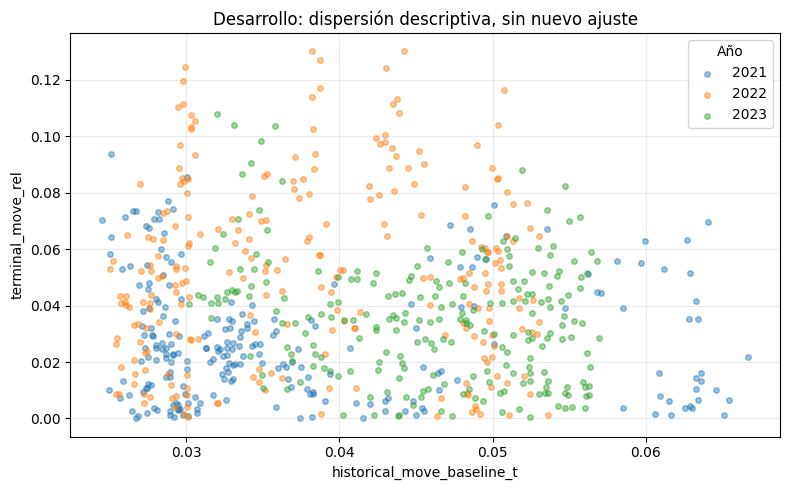

,year,rows,baseline_mean,baseline_median,baseline_q25,baseline_q75,terminal_mean,terminal_median,terminal_q25,terminal_q75
0,2021,233,0.037306,0.032673,0.028691,0.043175,0.027418,0.023146,0.010159,0.039309
1,2022,251,0.038261,0.037591,0.029793,0.048231,0.052418,0.050328,0.029378,0.074693
2,2023,231,0.045850,0.046626,0.039929,0.052434,0.035291,0.035053,0.017554,0.048144


In [4]:
development = audit['development'].copy()
fig, ax = plt.subplots(figsize=(8, 5))
for year, group in development.groupby('year'):
    ax.scatter(group['historical_move_baseline_t'], group['terminal_move_rel'], alpha=0.45, s=16, label=str(year))
ax.set(xlabel='historical_move_baseline_t', ylabel='terminal_move_rel',
       title='Desarrollo: dispersión descriptiva, sin nuevo ajuste')
ax.legend(title='Año')
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

display(audit['descriptive_by_year'])

## Conclusión de auditoría

La auditoría distingue dos posibilidades. Un error de construcción requeriría una discrepancia entre el linaje, H, k, las ventanas, sus fechas, el límite temporal, splits o el promedio recomputado. Si todas esas verificaciones coinciden, la pendiente negativa publicada describe la relación empírica de estas 715 observaciones bajo la definición congelada; no prueba causalidad ni justifica cambiar el benchmark después de verla.

El supuesto EOD no verificado y las limitaciones de opciones americanas permanecen.

## Mis notas

- 
- 
- 